In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score, recall_score,
    f1_score, roc_curve, precision_recall_curve, auc
)


In [24]:

# Step 1: Load and clean the dataset
df = pd.read_excel("combined_output11.xlsx")

# Standardize column names
df.columns = df.columns.str.strip().str.capitalize()  # Ensures 'Sentences' and 'Label'

# Drop rows with missing data
df = df.dropna(subset=['Sentences', 'Label'])

# Convert to proper types
df['Sentences'] = df['Sentences'].astype(str)
df['Label'] = df['Label'].astype(int)

In [25]:
df.shape

(2756, 2)

In [26]:
df.head(3)

,Sentences,Label
0,UN Humanitarian Chief Mark Lowcock today relea...,1
1,The announcement came as the World Health Orga...,0
2,The WHO has said there is still a chance of co...,1


In [27]:
# Step 2: Apply Bag of Words (BoW)
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['Sentences'])
y = df['Label'].values

In [28]:
# Step 3: Train/Validation/Test Split (60/20/20)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

In [29]:
# Step 4: Train the SVM classifier
model = SVC(kernel='linear', probability=True, random_state=42)
model.fit(X_train, y_train)

SVC(kernel='linear', probability=True, random_state=42)

In [30]:
# Step 5: Predict on validation set
y_pred = model.predict(X_val)
y_proba = model.predict_proba(X_val)[:, 1]

In [31]:
# Step 6: Evaluation Metrics
acc = accuracy_score(y_val, y_pred)
prec = precision_score(y_val, y_pred)
rec = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
cm = confusion_matrix(y_val, y_pred)

print(f"✅ Accuracy: {acc:.2f}")
print(f"🎯 Precision: {prec:.2f}")
print(f"📈 Recall: {rec:.2f}")
print(f"📊 F1 Score: {f1:.2f}")
print("🧮 Confusion Matrix:\n", cm)

✅ Accuracy: 0.99
🎯 Precision: 0.99
📈 Recall: 1.00
📊 F1 Score: 0.99
🧮 Confusion Matrix:
 [[137   3]
 [  2 409]]


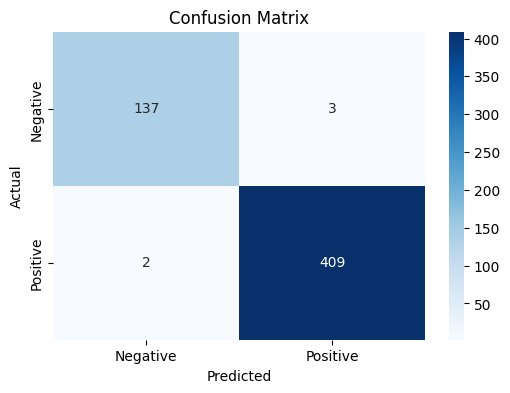

In [32]:
# Step 7: Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

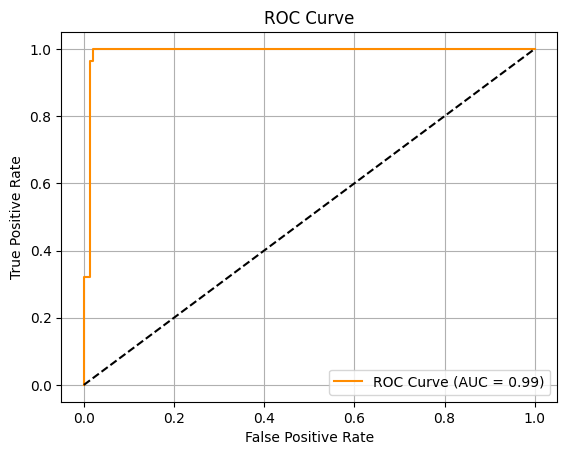

In [33]:
# Step 8: ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

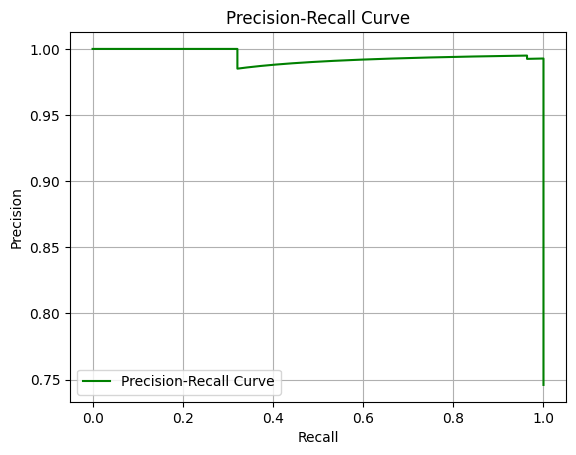

In [34]:
# Step 9: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_val, y_proba)

plt.figure()
plt.plot(recall, precision, label='Precision-Recall Curve', color='green')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid()
plt.show()
